# Fit Physical Fierz b by Event Reweighting

This notebook fits the physical Fierz parameter `b` directly, instead of fitting the template interpolation coordinate `c1`.

Method:

1. Use the `b=0` simulation as the detector/transport base sample.
2. Compute the Fierz shape factor from the raw beta spectra:

   `g(E) = raw_b1(E) / raw_b0(E) - 1`

3. For each `b=0` event, reweight by:

   `w_b(E) = 1 + b*g(E_primary)`

4. Apply the same HPGe and SiLi selections, then normalize the reweighted spectrum inside the fit window.
5. Fit target parquet files by scanning physical `b` and minimizing binned shape `χ²`.

Closure targets such as `22Na_b05.parquet` and `22Na_b25.parquet` are included so the notebook can verify that the method recovers known physical `b` values.

In [1]:
# Setup
from __future__ import annotations

from pathlib import Path
import os

_cache_root = Path.cwd() / "tmp" / "notebook_cache"
(_cache_root / "matplotlib").mkdir(parents=True, exist_ok=True)
(_cache_root / "xdg").mkdir(parents=True, exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(_cache_root / "matplotlib"))
os.environ.setdefault("XDG_CACHE_HOME", str(_cache_root / "xdg"))

%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import polars as pl

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 180,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

## Configuration

By default this notebook fits the double-511 HPGe-gated SiLi summed spectrum over `100-545 keV`. The target list includes closure samples and the nominal unknown target.

In [15]:
REPO = Path.cwd().resolve()
if REPO.name == "analysis":
    REPO = REPO.parent
elif REPO.name == "notebooks":
    REPO = REPO.parent.parent

OUTPUT_DIR = REPO / "output"
FIG_DIR = OUTPUT_DIR / "notebook_figures" / "fit_physical_b_reweighting"
FIG_DIR.mkdir(parents=True, exist_ok=True)

BASE_FILE = OUTPUT_DIR / "22Na_b0.parquet"
TARGETS = {
    "b05_closure": {"path": OUTPUT_DIR / "22Na_b05.parquet", "truth_b": 0.05},
    "b25_closure": {"path": OUTPUT_DIR / "22Na_b25.parquet", "truth_b": 0.25},
    "bT_target": {"path": OUTPUT_DIR / "22Na_bT.parquet", "truth_b": 0.01},
}
RAW_B0 = REPO / "22Na_0.raw"
RAW_B1 = REPO / "22Na_1.raw"

HPGE_511_WINDOW = (508.0, 514.0)
SILI_RANGE = (0.0, 700.0)
FIT_RANGE = (50.0, 545.0)
BIN_WIDTH = 2.0
BINS = np.arange(SILI_RANGE[0], SILI_RANGE[1] + BIN_WIDTH, BIN_WIDTH)
CENTERS = 0.5 * (BINS[:-1] + BINS[1:])
FIT_MASK = (CENTERS >= FIT_RANGE[0]) & (CENTERS <= FIT_RANGE[1])

# Physical b scan. Extend if you want wider limits.
B_GRID = np.linspace(-0.20, 0.60, 1601)

for path in [BASE_FILE, RAW_B0, RAW_B1] + [item["path"] for item in TARGETS.values()]:
    if path is not None and not path.exists():
        raise FileNotFoundError(path)

print(f"Repository: {REPO}")
print(f"Figures: {FIG_DIR}")
print(f"Base file: {BASE_FILE}")
print(f"Fit range: {FIT_RANGE[0]:g}-{FIT_RANGE[1]:g} keV")
print(f"HPGe gate: {HPGE_511_WINDOW[0]:g}-{HPGE_511_WINDOW[1]:g} keV in HPGe_1 and HPGe_2")

def savefig(fig: plt.Figure, name: str) -> None:
    path = FIG_DIR / name
    fig.savefig(path, bbox_inches="tight")
    print(path)

Repository: /Users/ronguy/Code/BpSpec/DualSiLi22Na
Figures: /Users/ronguy/Code/BpSpec/DualSiLi22Na/output/notebook_figures/fit_physical_b_reweighting
Base file: /Users/ronguy/Code/BpSpec/DualSiLi22Na/output/22Na_b0.parquet
Fit range: 50-545 keV
HPGe gate: 508-514 keV in HPGe_1 and HPGe_2


## Load the Fierz Shape Factor

The raw files are used only to compute the shape factor `g(E)`. The absolute normalization of the raw rates does not matter.

/Users/ronguy/Code/BpSpec/DualSiLi22Na/output/notebook_figures/fit_physical_b_reweighting/fierz_shape_factor_gE.png


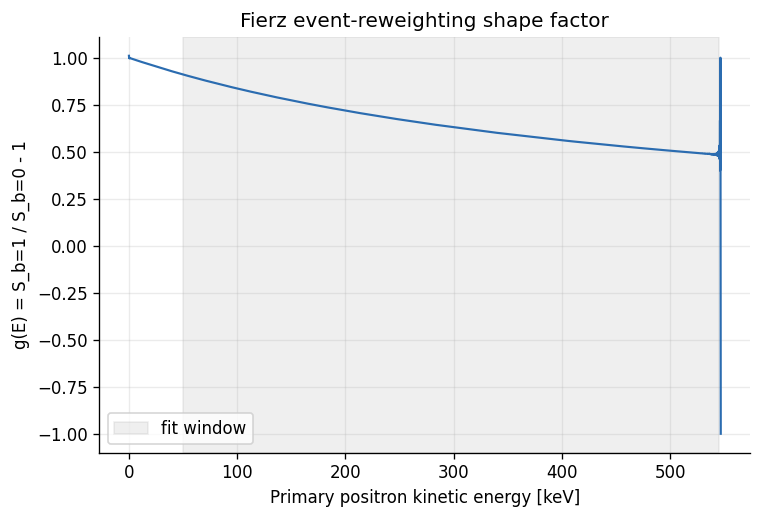

In [16]:
def read_raw_spectrum(path: Path) -> tuple[np.ndarray, np.ndarray]:
    energy = []
    rate = []
    with path.open() as f:
        for line in f:
            if not line.strip() or line.startswith("#"):
                continue
            parts = line.split()
            if len(parts) < 3:
                continue
            energy.append(float(parts[1]))
            rate.append(max(float(parts[2]), 0.0))
    return np.asarray(energy), np.asarray(rate)

raw_energy, raw_rate_b0 = read_raw_spectrum(RAW_B0)
raw_energy_b1, raw_rate_b1 = read_raw_spectrum(RAW_B1)
if not np.allclose(raw_energy, raw_energy_b1):
    raise ValueError("Raw b0 and b1 spectra have different energy grids")

raw_g = np.divide(raw_rate_b1, raw_rate_b0, out=np.zeros_like(raw_rate_b0), where=raw_rate_b0 > 0) - 1.0
# Avoid interpolation surprises outside the tabulated range.
raw_g = np.nan_to_num(raw_g, nan=0.0, posinf=0.0, neginf=0.0)

def g_of_energy(energy_keV: np.ndarray) -> np.ndarray:
    return np.interp(energy_keV, raw_energy, raw_g, left=raw_g[0], right=raw_g[-1])

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(raw_energy, raw_g, color="#2b6cb0", linewidth=1.3)
ax.axvspan(FIT_RANGE[0], FIT_RANGE[1], color="grey", alpha=0.12, label="fit window")
ax.set_xlabel("Primary positron kinetic energy [keV]")
ax.set_ylabel("g(E) = S_b=1 / S_b=0 - 1")
ax.set_title("Fierz event-reweighting shape factor")
ax.legend()
savefig(fig, "fierz_shape_factor_gE.png")
plt.show()

## Load Gated Event Samples

The event-level base sample keeps `primary_beta_kinetic_keV`, because that is what determines the reweighting. The target samples only need the SiLi sum and event weights.

In [17]:
def load_base_events(path: Path) -> pl.DataFrame:
    lo, hi = HPGE_511_WINDOW
    return (
        pl.scan_parquet(path)
        .select("E_SiLi_sum_keV", "E_HPGe_1_keV", "E_HPGe_2_keV", "event_weight", "primary_beta_kinetic_keV")
        .filter(
            (pl.col("E_HPGe_1_keV").is_between(lo, hi, closed="both"))
            & (pl.col("E_HPGe_2_keV").is_between(lo, hi, closed="both"))
            & (pl.col("E_SiLi_sum_keV") > 0)
            & (pl.col("E_SiLi_sum_keV").is_between(SILI_RANGE[0], SILI_RANGE[1], closed="left"))
            & (pl.col("primary_beta_kinetic_keV") > 0)
        )
        .collect()
    )


def load_target_events(path: Path) -> pl.DataFrame:
    lo, hi = HPGE_511_WINDOW
    return (
        pl.scan_parquet(path)
        .select("E_SiLi_sum_keV", "E_HPGe_1_keV", "E_HPGe_2_keV", "event_weight", "primary_beta_kinetic_keV")
        .filter(
            (pl.col("E_HPGe_1_keV").is_between(lo, hi, closed="both"))
            & (pl.col("E_HPGe_2_keV").is_between(lo, hi, closed="both"))
            & (pl.col("E_SiLi_sum_keV") > 0)
            & (pl.col("E_SiLi_sum_keV").is_between(SILI_RANGE[0], SILI_RANGE[1], closed="left"))
        )
        .collect()
    )

base_events = load_base_events(BASE_FILE)
target_events = {name: load_target_events(info["path"]) for name, info in TARGETS.items()}

sample_summary = pl.DataFrame([
    {"sample": "base_b0", "events_after_gate": len(base_events), "weighted_events": float(base_events["event_weight"].sum())},
    *[
        {"sample": name, "events_after_gate": len(df), "weighted_events": float(df["event_weight"].sum())}
        for name, df in target_events.items()
    ],
])
sample_summary

sample,events_after_gate,weighted_events
str,i64,f64
"""base_b0""",839410,839410.0
"""b05_closure""",839159,839159.0
"""b25_closure""",840513,840513.0
"""bT_target""",839777,839777.0


## Histogram and Fit Functions

For each physical `b`, the model histogram is built from `b=0` events with event weights multiplied by `1 + b*g(E_primary)`. The model is then normalized in the same fit window as the target.

In [18]:
base_energy = base_events["E_SiLi_sum_keV"].to_numpy()
base_primary = base_events["primary_beta_kinetic_keV"].to_numpy()
base_event_weight = base_events["event_weight"].cast(pl.Float64).to_numpy()
base_g = g_of_energy(base_primary)

# Since this is a Fierz factor, weights should stay positive in the scanned range.
scan_endpoint_weights = 1.0 + B_GRID[:, None] * np.array([base_g.min(), base_g.max()])[None, :]
print(f"base g(E) range after gate: {base_g.min():.4f} to {base_g.max():.4f}")
print(f"min event reweight over scan endpoints: {scan_endpoint_weights.min():.4f}")


def weighted_hist(values: np.ndarray, weights: np.ndarray, bins: np.ndarray = BINS) -> tuple[np.ndarray, np.ndarray]:
    h, _ = np.histogram(values, bins=bins, weights=weights)
    v, _ = np.histogram(values, bins=bins, weights=weights * weights)
    return h.astype(float), v.astype(float)


def hist_values(values: np.ndarray, weights: np.ndarray, bins: np.ndarray = BINS) -> np.ndarray:
    h, _ = np.histogram(values, bins=bins, weights=weights)
    return h.astype(float)


# Precompute the linear and quadratic pieces of the reweighted base histogram.
# H_b = H_0 + b * H_g
# Var(H_b) = V_0 + 2*b*V_g + b^2*V_gg
base_hist_0 = hist_values(base_energy, base_event_weight)
base_hist_g = hist_values(base_energy, base_event_weight * base_g)
base_var_0 = hist_values(base_energy, base_event_weight * base_event_weight)
base_var_g = hist_values(base_energy, base_event_weight * base_event_weight * base_g)
base_var_gg = hist_values(base_energy, base_event_weight * base_event_weight * base_g * base_g)


def normalize_hist(h: np.ndarray, v: np.ndarray, mask: np.ndarray = FIT_MASK) -> tuple[np.ndarray, np.ndarray, float]:
    total = float(np.sum(h[mask]))
    if total <= 0:
        raise ValueError("Cannot normalize an empty histogram")
    return h / total, v / (total * total), total


def model_for_b(physical_b: float) -> dict:
    h = base_hist_0 + physical_b * base_hist_g
    v = base_var_0 + 2.0 * physical_b * base_var_g + physical_b * physical_b * base_var_gg
    v = np.maximum(v, 0.0)
    p, vp, n = normalize_hist(h, v)
    return {"b": physical_b, "hist": h, "var": v, "prob": p, "prob_var": vp, "fit_norm": n}


def target_hist(df: pl.DataFrame) -> dict:
    e = df["E_SiLi_sum_keV"].to_numpy()
    w = df["event_weight"].cast(pl.Float64).to_numpy()
    h, v = weighted_hist(e, w)
    p, vp, n = normalize_hist(h, v)
    return {"hist": h, "var": v, "prob": p, "prob_var": vp, "fit_norm": n}


def chi2_for_target(target: dict, physical_b: float, include_model_stat: bool = True) -> dict:
    model = model_for_b(physical_b)
    sigma2 = target["prob_var"].copy()
    if include_model_stat:
        sigma2 = sigma2 + model["prob_var"]
    good = FIT_MASK & np.isfinite(sigma2) & (sigma2 > 0) & (target["prob"] > 0) & (model["prob"] > 0)
    resid = target["prob"][good] - model["prob"][good]
    chi2 = float(np.sum(resid * resid / sigma2[good]))
    return {"b": physical_b, "chi2": chi2, "n_bins": int(np.count_nonzero(good)), "model": model, "good": good}


def fit_physical_b(target: dict, b_grid: np.ndarray = B_GRID, include_model_stat: bool = True) -> dict:
    chi2_values = []
    n_bins = None
    for b in b_grid:
        row = chi2_for_target(target, float(b), include_model_stat=include_model_stat)
        chi2_values.append(row["chi2"])
        n_bins = row["n_bins"]
    chi2 = np.asarray(chi2_values)
    idx = int(np.argmin(chi2))
    b_best_grid = float(b_grid[idx])

    # Parabolic refinement around the minimum if possible.
    if 0 < idx < len(b_grid) - 1:
        xs = b_grid[idx - 1:idx + 2]
        ys = chi2[idx - 1:idx + 2]
        a, c, d = np.polyfit(xs, ys, 2)
        if a > 0:
            b_best = float(-c / (2.0 * a))
            chi2_min = float(np.polyval([a, c, d], b_best))
            b_err = float(np.sqrt(1.0 / a))  # Delta chi2=1 for one parameter.
        else:
            b_best = b_best_grid
            chi2_min = float(chi2[idx])
            b_err = np.nan
    else:
        b_best = b_best_grid
        chi2_min = float(chi2[idx])
        b_err = np.nan

    best = chi2_for_target(target, b_best, include_model_stat=include_model_stat)
    dof = max(1, best["n_bins"] - 1)
    return {
        "b_best": b_best,
        "b_err": b_err,
        "chi2_min": chi2_min,
        "dof": dof,
        "chi2_ndf": chi2_min / dof,
        "grid_b": b_grid,
        "grid_chi2": chi2,
        "best_model": best["model"],
        "good": best["good"],
    }

base g(E) range after gate: 0.4846 to 0.9946
min event reweight over scan endpoints: 0.8011


## Closure Fits and Target Fit

The closure rows should recover the known physical `b` values. If they do not, the reweighting model is not adequate for the selected observable or cuts.

In [19]:
target_hists = {name: target_hist(df) for name, df in target_events.items()}
fit_results = {name: fit_physical_b(target) for name, target in target_hists.items()}

summary_rows = []
for name, fit in fit_results.items():
    truth = TARGETS[name]["truth_b"]
    summary_rows.append({
        "target": name,
        "truth_b": truth,
        "fit_b": fit["b_best"],
        "fit_b_err": fit["b_err"],
        "pull_vs_truth": None if truth is None else (fit["b_best"] - truth) / fit["b_err"],
        "chi2": fit["chi2_min"],
        "dof": fit["dof"],
        "chi2_ndf": fit["chi2_ndf"],
    })
fit_summary = pl.DataFrame(summary_rows)
fit_summary

target,truth_b,fit_b,fit_b_err,pull_vs_truth,chi2,dof,chi2_ndf
str,f64,f64,f64,f64,f64,i64,f64
"""b05_closure""",0.05,0.046159,0.017803,-0.215748,79.604953,245,0.324918
"""b25_closure""",0.25,0.263356,0.023527,0.567689,223.005007,245,0.910225
"""bT_target""",0.01,0.009282,0.016922,-0.042444,24.562255,245,0.100254


/Users/ronguy/Code/BpSpec/DualSiLi22Na/output/notebook_figures/fit_physical_b_reweighting/physical_b_likelihood_scans.png


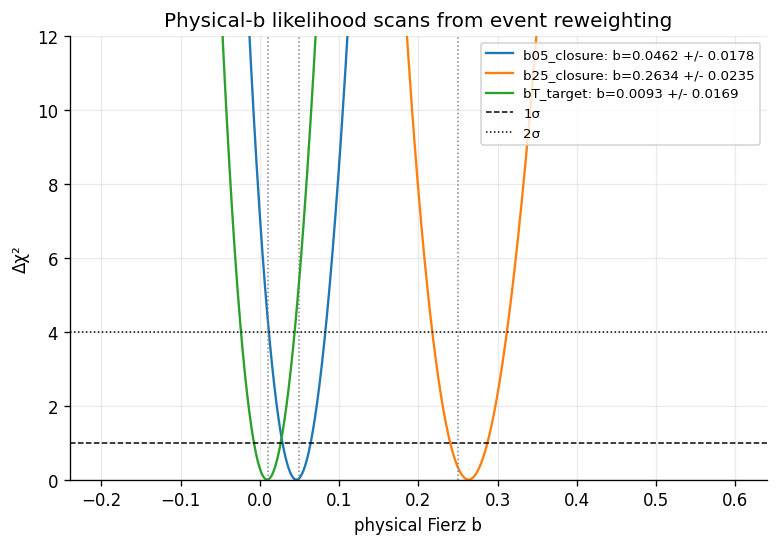

In [20]:
fig, ax = plt.subplots(figsize=(7.5, 4.8))
for name, fit in fit_results.items():
    delta = fit["grid_chi2"] - np.min(fit["grid_chi2"])
    ax.plot(fit["grid_b"], delta, linewidth=1.4, label=f"{name}: b={fit['b_best']:.4f} +/- {fit['b_err']:.4f}")
    truth = TARGETS[name]["truth_b"]
    if truth is not None:
        ax.axvline(truth, color="grey", linestyle=":", linewidth=0.9)
ax.axhline(1.0, color="black", linestyle="--", linewidth=0.9, label="1σ")
ax.axhline(4.0, color="black", linestyle=":", linewidth=0.9, label="2σ")
ax.set_xlabel("physical Fierz b")
ax.set_ylabel("Δχ²")
ax.set_ylim(0, 12)
ax.set_title("Physical-b likelihood scans from event reweighting")
ax.legend(fontsize=8)
savefig(fig, "physical_b_likelihood_scans.png")
plt.show()

## Spectrum Overlays

These plots compare each target spectrum to the best-fit reweighted `b=0` prediction. Closure targets should visually agree with their best-fit model.

/Users/ronguy/Code/BpSpec/DualSiLi22Na/output/notebook_figures/fit_physical_b_reweighting/physical_b_best_fit_spectra.png


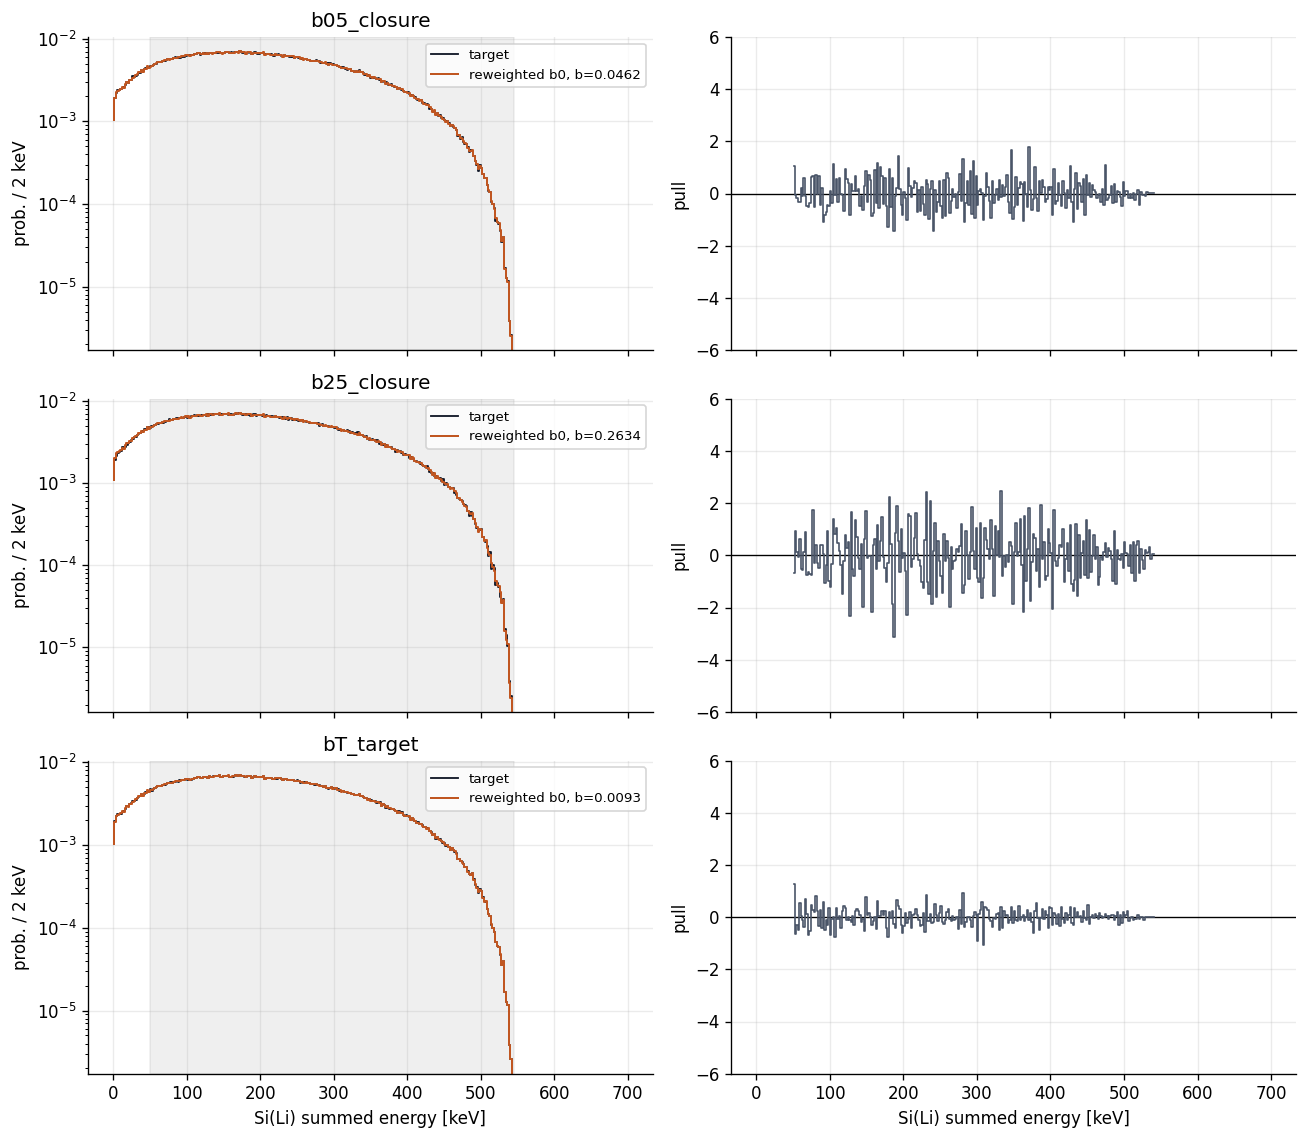

In [21]:
fig, axes = plt.subplots(len(TARGETS), 2, figsize=(11, 3.2 * len(TARGETS)), sharex=True)
if len(TARGETS) == 1:
    axes = np.asarray([axes])

for row, (name, target) in enumerate(target_hists.items()):
    fit = fit_results[name]
    model = fit["best_model"]
    good = fit["good"]
    ax, rax = axes[row]
    ax.step(CENTERS, target["prob"], where="mid", color="#111827", linewidth=1.1, label="target")
    ax.step(CENTERS, model["prob"], where="mid", color="#c05621", linewidth=1.2, label=f"reweighted b0, b={fit['b_best']:.4f}")
    ax.axvspan(FIT_RANGE[0], FIT_RANGE[1], color="grey", alpha=0.12)
    ax.set_yscale("log")
    ax.set_ylabel(f"prob. / {BIN_WIDTH:g} keV")
    ax.set_title(name)
    ax.legend(fontsize=8)

    sigma = np.sqrt(target["prob_var"] + model["prob_var"])
    pull = np.full_like(CENTERS, np.nan, dtype=float)
    pull[good] = (target["prob"][good] - model["prob"][good]) / sigma[good]
    rax.axhline(0, color="black", linewidth=0.8)
    rax.step(CENTERS[good], pull[good], where="mid", color="#4a5568", linewidth=1.0)
    rax.set_ylabel("pull")
    rax.set_ylim(-6, 6)

axes[-1, 0].set_xlabel("Si(Li) summed energy [keV]")
axes[-1, 1].set_xlabel("Si(Li) summed energy [keV]")
fig.tight_layout()
savefig(fig, "physical_b_best_fit_spectra.png")
plt.show()

## Compare with Template Coordinate c

This diagnostic shows why `c1` from normalized `b0/b1` templates should not be quoted as physical `b`.

In [22]:
model_b0 = model_for_b(0.0)
model_b1 = model_for_b(1.0)

def template_coordinate_for_target(target: dict) -> float:
    p0 = model_b0["prob"]
    p1 = model_b1["prob"]
    pT = target["prob"]
    d = p1[FIT_MASK] - p0[FIT_MASK]
    r = pT[FIT_MASK] - p0[FIT_MASK]
    return float(np.sum(d * r) / np.sum(d * d))

coord_rows = []
for name, target in target_hists.items():
    c = template_coordinate_for_target(target)
    coord_rows.append({
        "target": name,
        "truth_b": TARGETS[name]["truth_b"],
        "template_coordinate_c": c,
        "physical_b_from_reweight_fit": fit_results[name]["b_best"],
    })
coordinate_summary = pl.DataFrame(coord_rows)
coordinate_summary

target,truth_b,template_coordinate_c,physical_b_from_reweight_fit
str,f64,f64,f64
"""b05_closure""",0.05,0.080731,0.046159
"""b25_closure""",0.25,0.376427,0.263356
"""bT_target""",0.01,0.017613,0.009282


## Export Results

In [23]:
fit_summary.write_csv(FIG_DIR / "physical_b_reweighting_fit_summary.csv")
coordinate_summary.write_csv(FIG_DIR / "template_coordinate_vs_physical_b.csv")

# Save binned best-fit spectra for downstream checks.
rows = []
for name, target in target_hists.items():
    model = fit_results[name]["best_model"]
    for e, target_p, target_v, model_p, model_v, in_fit in zip(
        CENTERS, target["prob"], target["prob_var"], model["prob"], model["prob_var"], FIT_MASK
    ):
        rows.append({
            "target": name,
            "energy_center_keV": e,
            "in_fit_window": bool(in_fit),
            "target_prob": target_p,
            "target_prob_var": target_v,
            "model_prob": model_p,
            "model_prob_var": model_v,
        })
pl.DataFrame(rows).write_csv(FIG_DIR / "physical_b_reweighting_binned_spectra.csv")

print(FIG_DIR / "physical_b_reweighting_fit_summary.csv")
print(FIG_DIR / "template_coordinate_vs_physical_b.csv")
print(FIG_DIR / "physical_b_reweighting_binned_spectra.csv")

/Users/ronguy/Code/BpSpec/DualSiLi22Na/output/notebook_figures/fit_physical_b_reweighting/physical_b_reweighting_fit_summary.csv
/Users/ronguy/Code/BpSpec/DualSiLi22Na/output/notebook_figures/fit_physical_b_reweighting/template_coordinate_vs_physical_b.csv
/Users/ronguy/Code/BpSpec/DualSiLi22Na/output/notebook_figures/fit_physical_b_reweighting/physical_b_reweighting_binned_spectra.csv


## Reading the Result

Use `fit_b` as the physical Fierz parameter. The template coordinate `c` is only a diagnostic and should not be interpreted as `b`.

If the closure rows do not recover `b=0.05` and `b=0.25`, then the selected observable/cuts require a more detailed detector-response model or additional nuisance parameters.